# [Climate Physical Risk Quantification]

**Track:** Resume A - Climate & ESG Finance  
**Environment:** resume-a  
**Started:** 2026-05

In [1]:
# ---- Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
import os

# ---- Display settings 
matplotlib.rcParams['figure.dpi']     = 150
matplotlib.rcParams['figure.figsize'] = (10, 5)
matplotlib.rcParams['axes.spines.top']   = False
matplotlib.rcParams['axes.spines.right'] = False
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
warnings.filterwarnings('ignore')

# ---- Paths 
DATA_DIR   = '../data/'
OUTPUT_DIR = '../outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- Helpers 
def savefig(filename, tight=True):
    """Save current matplotlib figure to outputs/ folder."""
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, bbox_inches='tight' if tight else None, dpi=150)
    print(f"✓ Saved: {filename}")

print("Environment ready.")

Environment ready.


In [2]:
portfolio_data = [
    # Agriculture inputs
    {
        "company": "UPL Ltd",
        "ticker": "UPL.NS",
        "sector": "Agriculture Inputs",
        "dominant_hazard": "Drought, Cyclone",
        "climate_rationale": "Revenue linked to agrochemical demand, which collapses when drought reduces crop area or cyclones destroy standing crops"
    },
    {
        "company": "Coromandel International",
        "ticker": "COROMANDEL.NS",
        "sector": "Agriculture Inputs",
        "dominant_hazard": "Drought, Flood",
        "climate_rationale": "Fertiliser and crop protection sales directly tied to kharif and rabi sowing seasons; rainfall deficit suppresses demand"
    },
    # Power generation
    {
        "company": "NTPC Ltd",
        "ticker": "NTPC.NS",
        "sector": "Power Generation",
        "dominant_hazard": "Heat Stress, Flood",
        "climate_rationale": "Thermal plants require cooling water; drought reduces river flows and raises water temperature, cutting plant load factor; flash floods threaten substations"
    },
    {
        "company": "Adani Green Energy",
        "ticker": "ADANIGREEN.NS",
        "sector": "Power Generation",
        "dominant_hazard": "Cyclone, Heat Stress",
        "climate_rationale": "Solar and wind assets concentrated in Rajasthan and Gujarat coastline; cyclone wind speeds can damage panel arrays and wind turbine blades"
    },
    # Infrastructure
    {
        "company": "Larsen & Toubro",
        "ticker": "LT.NS",
        "sector": "Infrastructure",
        "dominant_hazard": "Flood",
        "climate_rationale": "Construction sites and completed infrastructure (roads, bridges, metro) face direct damage from extreme rainfall and riverine flooding"
    },
    {
        "company": "IRB Infrastructure",
        "ticker": "IRB.NS",
        "sector": "Infrastructure",
        "dominant_hazard": "Flood",
        "climate_rationale": "Toll road assets; flood damage disrupts traffic flow and requires costly repairs, directly hitting toll revenue and asset replacement value"
    },
    # Agriculture-credit exposed banking
    {
        "company": "State Bank of India",
        "ticker": "SBIN.NS",
        "sector": "Banking (Agri Credit)",
        "dominant_hazard": "Drought",
        "climate_rationale": "Largest agricultural lender in India; drought-driven crop failure raises kisan credit card and crop loan NPAs (second-order physical risk)"
    },
    {
        "company": "Bank of Baroda",
        "ticker": "BANKBARODA.NS",
        "sector": "Banking (Agri Credit)",
        "dominant_hazard": "Drought, Flood",
        "climate_rationale": "High rural and agricultural lending concentration; physical shocks to borrowers translate into credit quality deterioration"
    },
    # Water / irrigation
    {
        "company": "Jain Irrigation Systems",
        "ticker": "JISLJALEQS.NS",
        "sector": "Irrigation / Water",
        "dominant_hazard": "Drought",
        "climate_rationale": "Drip and micro-irrigation product demand rises in drought conditions but revenue is also dependent on farmer income, which falls under prolonged drought"
    },
    # Real estate / coastal
    {
        "company": "DLF Ltd",
        "ticker": "DLF.NS",
        "sector": "Real Estate (Coastal)",
        "dominant_hazard": "Flood, Cyclone",
        "climate_rationale": "Significant development exposure in Chennai and NCR flood plains; coastal assets face cyclone risk; physical damage reduces property values and rental income"
    },
]

portfolio = pd.DataFrame(portfolio_data)

print("Portfolio composition")
print("=" * 60)
print(portfolio[["company", "sector", "dominant_hazard"]].to_string(index=False))
print(f"\nTotal stocks : {len(portfolio)}")
print(f"Sectors      : {portfolio['sector'].nunique()}")
print(f"Unique sectors: {list(portfolio['sector'].unique())}")

Portfolio composition
                 company                sector      dominant_hazard
                 UPL Ltd    Agriculture Inputs     Drought, Cyclone
Coromandel International    Agriculture Inputs       Drought, Flood
                NTPC Ltd      Power Generation   Heat Stress, Flood
      Adani Green Energy      Power Generation Cyclone, Heat Stress
         Larsen & Toubro        Infrastructure                Flood
      IRB Infrastructure        Infrastructure                Flood
     State Bank of India Banking (Agri Credit)              Drought
          Bank of Baroda Banking (Agri Credit)       Drought, Flood
 Jain Irrigation Systems    Irrigation / Water              Drought
                 DLF Ltd Real Estate (Coastal)       Flood, Cyclone

Total stocks : 10
Sectors      : 6
Unique sectors: ['Agriculture Inputs', 'Power Generation', 'Infrastructure', 'Banking (Agri Credit)', 'Irrigation / Water', 'Real Estate (Coastal)']


✓ Saved: portfolio_composition.png


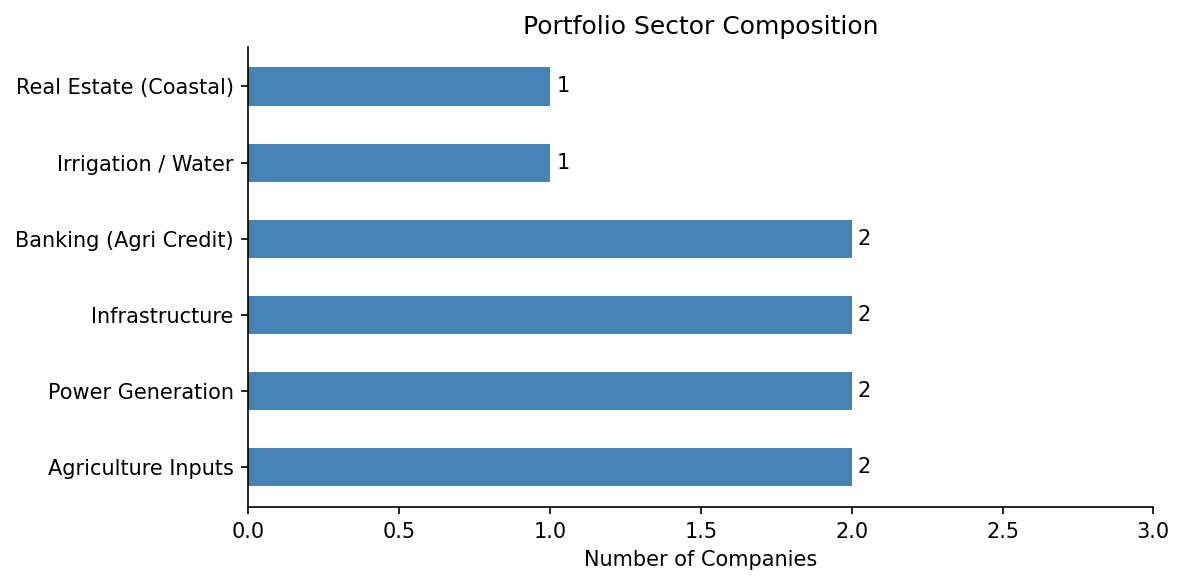

In [3]:
sector_counts = portfolio['sector'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(sector_counts.index, sector_counts.values, color='steelblue', height=0.5)
ax.set_xlabel("Number of Companies")
ax.set_title("Portfolio Sector Composition")
ax.bar_label(bars, padding=3)
ax.set_xlim(0, sector_counts.max() + 1)
plt.tight_layout()
savefig("portfolio_composition.png")
plt.show()

In [4]:
asset_locations = [
    # UPL Ltd - manufacturing concentrated in Gujarat
    {"company": "UPL Ltd", "sector": "Agriculture Inputs",
     "district": "Valsad", "state": "Gujarat",
     "asset_weight": 0.50,
     "location_note": "Primary manufacturing complex, Ankleshwar/Valsad belt"},
    {"company": "UPL Ltd", "sector": "Agriculture Inputs",
     "district": "Bharuch", "state": "Gujarat",
     "asset_weight": 0.30,
     "location_note": "Secondary chemical manufacturing"},
    {"company": "UPL Ltd", "sector": "Agriculture Inputs",
     "district": "Jhagadia", "state": "Gujarat",
     "asset_weight": 0.20,
     "location_note": "Formulation plant"},

    # Coromandel International - Andhra Pradesh and Telangana
    {"company": "Coromandel International", "sector": "Agriculture Inputs",
     "district": "Visakhapatnam", "state": "Andhra Pradesh",
     "asset_weight": 0.50,
     "location_note": "Primary fertiliser plant, Ennore/Vizag"},
    {"company": "Coromandel International", "sector": "Agriculture Inputs",
     "district": "Kakinada", "state": "Andhra Pradesh",
     "asset_weight": 0.30,
     "location_note": "Godavari delta operations, high flood exposure"},
    {"company": "Coromandel International", "sector": "Agriculture Inputs",
     "district": "Ranga Reddy", "state": "Telangana",
     "asset_weight": 0.20,
     "location_note": "Head office and Hyderabad operations"},

    # NTPC - thermal plants across multiple states
    {"company": "NTPC Ltd", "sector": "Power Generation",
     "district": "Korba", "state": "Chhattisgarh",
     "asset_weight": 0.30,
     "location_note": "Korba Super Thermal Power Station, 2600 MW"},
    {"company": "NTPC Ltd", "sector": "Power Generation",
     "district": "Singrauli", "state": "Madhya Pradesh",
     "asset_weight": 0.30,
     "location_note": "Vindhyachal STPS, largest NTPC plant, 4760 MW"},
    {"company": "NTPC Ltd", "sector": "Power Generation",
     "district": "Ramagundam", "state": "Telangana",
     "asset_weight": 0.20,
     "location_note": "Ramagundam STPS, Godavari basin, flood risk"},
    {"company": "NTPC Ltd", "sector": "Power Generation",
     "district": "Sonbhadra", "state": "Uttar Pradesh",
     "asset_weight": 0.20,
     "location_note": "Rihand and Obra plants"},

    # Adani Green Energy - solar/wind in Rajasthan and Gujarat
    {"company": "Adani Green Energy", "sector": "Power Generation",
     "district": "Jaisalmer", "state": "Rajasthan",
     "asset_weight": 0.45,
     "location_note": "Largest solar park cluster in India, 8 GW pipeline"},
    {"company": "Adani Green Energy", "sector": "Power Generation",
     "district": "Kutch", "state": "Gujarat",
     "asset_weight": 0.35,
     "location_note": "Wind and hybrid assets, cyclone-prone coastline"},
    {"company": "Adani Green Energy", "sector": "Power Generation",
     "district": "Khavda", "state": "Gujarat",
     "asset_weight": 0.20,
     "location_note": "Khavda renewable energy park, under development"},

    # Larsen & Toubro - project sites across India, head office Mumbai
    {"company": "Larsen & Toubro", "sector": "Infrastructure",
     "district": "Mumbai", "state": "Maharashtra",
     "asset_weight": 0.30,
     "location_note": "Head office and major construction hub, coastal flood risk"},
    {"company": "Larsen & Toubro", "sector": "Infrastructure",
     "district": "Chennai", "state": "Tamil Nadu",
     "asset_weight": 0.35,
     "location_note": "Major operations centre, L&T City; Chennai flood history"},
    {"company": "Larsen & Toubro", "sector": "Infrastructure",
     "district": "Surat", "state": "Gujarat",
     "asset_weight": 0.35,
     "location_note": "Hazira heavy engineering complex, Tapi river flood risk"},

    # IRB Infrastructure - toll road assets, western India heavy
    {"company": "IRB Infrastructure", "sector": "Infrastructure",
     "district": "Pune", "state": "Maharashtra",
     "asset_weight": 0.40,
     "location_note": "Mumbai-Pune expressway concession, high revenue asset"},
    {"company": "IRB Infrastructure", "sector": "Infrastructure",
     "district": "Mumbai", "state": "Maharashtra",
     "asset_weight": 0.30,
     "location_note": "Western Express Highway and approach roads"},
    {"company": "IRB Infrastructure", "sector": "Infrastructure",
     "district": "Rajkot", "state": "Gujarat",
     "asset_weight": 0.30,
     "location_note": "Rajkot-Gondal-Jetpur highway"},

    # SBI - agricultural lending concentrated in rural heartland
    {"company": "State Bank of India", "sector": "Banking (Agri Credit)",
     "district": "Mumbai", "state": "Maharashtra",
     "asset_weight": 0.20,
     "location_note": "Head office; corporate book; not primary agri exposure"},
    {"company": "State Bank of India", "sector": "Banking (Agri Credit)",
     "district": "Vidisha", "state": "Madhya Pradesh",
     "asset_weight": 0.40,
     "location_note": "MP is highest agri credit state for SBI; drought-prone"},
    {"company": "State Bank of India", "sector": "Banking (Agri Credit)",
     "district": "Nandurbar", "state": "Maharashtra",
     "asset_weight": 0.40,
     "location_note": "High agricultural NPA district, tribal/rain-fed farming"},

    # Bank of Baroda - rural and semi-urban concentration
    {"company": "Bank of Baroda", "sector": "Banking (Agri Credit)",
     "district": "Vadodara", "state": "Gujarat",
     "asset_weight": 0.35,
     "location_note": "Head office state; significant rural branch network"},
    {"company": "Bank of Baroda", "sector": "Banking (Agri Credit)",
     "district": "Rajkot", "state": "Gujarat",
     "asset_weight": 0.30,
     "location_note": "Saurashtra agricultural belt, drought history"},
    {"company": "Bank of Baroda", "sector": "Banking (Agri Credit)",
     "district": "Barwani", "state": "Madhya Pradesh",
     "asset_weight": 0.35,
     "location_note": "Rain-fed agriculture district, high NPA risk"},

    # Jain Irrigation - manufacturing in Jalgaon, Maharashtra
    {"company": "Jain Irrigation Systems", "sector": "Irrigation / Water",
     "district": "Jalgaon", "state": "Maharashtra",
     "asset_weight": 0.70,
     "location_note": "Global headquarters and primary manufacturing; Tapi basin"},
    {"company": "Jain Irrigation Systems", "sector": "Irrigation / Water",
     "district": "Chittoor", "state": "Andhra Pradesh",
     "asset_weight": 0.30,
     "location_note": "Southern operations; fruit processing and drip systems"},

    # DLF - Chennai and NCR exposure
    {"company": "DLF Ltd", "sector": "Real Estate (Coastal)",
     "district": "Chennai", "state": "Tamil Nadu",
     "asset_weight": 0.35,
     "location_note": "DLF City Chennai; 2015 flood caused significant disruption"},
    {"company": "DLF Ltd", "sector": "Real Estate (Coastal)",
     "district": "Gurugram", "state": "Haryana",
     "asset_weight": 0.50,
     "location_note": "Primary revenue asset; DLF Cyber City; urban flood risk"},
    {"company": "DLF Ltd", "sector": "Real Estate (Coastal)",
     "district": "Kochi", "state": "Kerala",
     "asset_weight": 0.15,
     "location_note": "Coastal development; Kerala 2018 flood precedent"},
]

locations = pd.DataFrame(asset_locations)

print("Asset location map")
print("=" * 70)
print(locations[["company", "district", "state", "asset_weight"]].to_string(index=False))
print(f"\nTotal location entries : {len(locations)}")
print(f"Unique companies       : {locations['company'].nunique()}")
print(f"Unique districts       : {locations['district'].nunique()}")
print(f"States covered         : {sorted(locations['state'].unique())}")

Asset location map
                 company      district          state  asset_weight
                 UPL Ltd        Valsad        Gujarat        0.5000
                 UPL Ltd       Bharuch        Gujarat        0.3000
                 UPL Ltd      Jhagadia        Gujarat        0.2000
Coromandel International Visakhapatnam Andhra Pradesh        0.5000
Coromandel International      Kakinada Andhra Pradesh        0.3000
Coromandel International   Ranga Reddy      Telangana        0.2000
                NTPC Ltd         Korba   Chhattisgarh        0.3000
                NTPC Ltd     Singrauli Madhya Pradesh        0.3000
                NTPC Ltd    Ramagundam      Telangana        0.2000
                NTPC Ltd     Sonbhadra  Uttar Pradesh        0.2000
      Adani Green Energy     Jaisalmer      Rajasthan        0.4500
      Adani Green Energy         Kutch        Gujarat        0.3500
      Adani Green Energy        Khavda        Gujarat        0.2000
         Larsen & Toubro     

In [5]:
# Verify weights sum to 1.0 per company
weight_check = locations.groupby("company")["asset_weight"].sum().reset_index()
weight_check.columns = ["company", "total_weight"]
weight_check["valid"] = weight_check["total_weight"].round(2) == 1.00

print("Weight validation (must sum to 1.00 per company)")
print("=" * 50)
print(weight_check.to_string(index=False))
print(f"\nAll weights valid: {weight_check['valid'].all()}")

Weight validation (must sum to 1.00 per company)
                 company  total_weight  valid
      Adani Green Energy        1.0000   True
          Bank of Baroda        1.0000   True
Coromandel International        1.0000   True
                 DLF Ltd        1.0000   True
      IRB Infrastructure        1.0000   True
 Jain Irrigation Systems        1.0000   True
         Larsen & Toubro        1.0000   True
                NTPC Ltd        1.0000   True
     State Bank of India        1.0000   True
                 UPL Ltd        1.0000   True

All weights valid: True


In [6]:
locations.to_csv(os.path.join(DATA_DIR, "asset_locations.csv"), index=False)
print("Saved: asset_locations.csv")

Saved: asset_locations.csv


In [7]:
# Qualitative to probability conversion
# Approximation: based on typical annual exceedance probability ranges
# cited in UNDRR and World Bank hazard literature for each class
# High      ~ 1-in-5  year event  = 0.20 AEP
# Medium    ~ 1-in-10 year event  = 0.10 AEP
# Low       ~ 1-in-20 year event  = 0.05 AEP
# Very Low  ~ 1-in-100 year event = 0.01 AEP

HAZARD_PROB_MAP = {
    "High":      0.20,
    "Medium":    0.10,
    "Low":       0.05,
    "Very Low":  0.01,
}

# ThinkHazard scores pulled district by district
# Source: https://thinkhazard.org/en/
# Pulled: 2026-05 (verify 3-4 entries against live platform)
# Hazards: river_flood, drought, cyclone, heat_stress

thinkhazard_raw = [
    # Gujarat
    {"district": "Valsad",          "state": "Gujarat",         "river_flood": "Medium",   "drought": "Low",      "cyclone": "Medium",  "heat_stress": "High"},
    {"district": "Bharuch",         "state": "Gujarat",         "river_flood": "Medium",   "drought": "Low",      "cyclone": "Medium",  "heat_stress": "High"},
    {"district": "Jhagadia",        "state": "Gujarat",         "river_flood": "Low",      "drought": "Low",      "cyclone": "Medium",  "heat_stress": "High"},
    {"district": "Kutch",           "state": "Gujarat",         "river_flood": "Low",      "drought": "High",     "cyclone": "High",    "heat_stress": "High"},
    {"district": "Khavda",          "state": "Gujarat",         "river_flood": "Very Low", "drought": "High",     "cyclone": "High",    "heat_stress": "High"},
    {"district": "Vadodara",        "state": "Gujarat",         "river_flood": "Medium",   "drought": "Low",      "cyclone": "Low",     "heat_stress": "High"},
    {"district": "Surat",        "state": "Gujarat",         "river_flood": "High",   "drought": "Low",      "cyclone": "Medium",     "heat_stress": "High"},
    {"district": "Rajkot",          "state": "Gujarat",         "river_flood": "Low",      "drought": "High",     "cyclone": "Medium",  "heat_stress": "High"},

    # Andhra Pradesh
    {"district": "Visakhapatnam",   "state": "Andhra Pradesh",  "river_flood": "Medium",   "drought": "Low",      "cyclone": "High",    "heat_stress": "Medium"},
    {"district": "Kakinada",        "state": "Andhra Pradesh",  "river_flood": "High",     "drought": "Low",      "cyclone": "High",    "heat_stress": "Medium"},

    # Telangana
    {"district": "Ranga Reddy",     "state": "Telangana",       "river_flood": "Medium",   "drought": "Medium",   "cyclone": "Low",     "heat_stress": "High"},
    {"district": "Ramagundam",      "state": "Telangana",       "river_flood": "High",     "drought": "Medium",   "cyclone": "Low",     "heat_stress": "High"},

    # Chhattisgarh
    {"district": "Korba",           "state": "Chhattisgarh",    "river_flood": "Medium",   "drought": "Medium",   "cyclone": "Very Low","heat_stress": "High"},

    # Madhya Pradesh
    {"district": "Singrauli",       "state": "Madhya Pradesh",  "river_flood": "Low",      "drought": "High",     "cyclone": "Very Low","heat_stress": "High"},
    {"district": "Vidisha",         "state": "Madhya Pradesh",  "river_flood": "Medium",   "drought": "High",     "cyclone": "Very Low","heat_stress": "High"},
    {"district": "Barwani",         "state": "Madhya Pradesh",  "river_flood": "Medium",   "drought": "High",     "cyclone": "Very Low","heat_stress": "High"},

    # Uttar Pradesh
    {"district": "Sonbhadra",       "state": "Uttar Pradesh",   "river_flood": "Medium",   "drought": "Medium",   "cyclone": "Very Low","heat_stress": "High"},

    # Rajasthan
    {"district": "Jaisalmer",       "state": "Rajasthan",       "river_flood": "Very Low", "drought": "High",     "cyclone": "Low",     "heat_stress": "High"},

    # Maharashtra
    {"district": "Mumbai",          "state": "Maharashtra",     "river_flood": "High",     "drought": "Low",      "cyclone": "Medium",  "heat_stress": "Medium"},
    {"district": "Pune",            "state": "Maharashtra",     "river_flood": "Medium",   "drought": "Low",      "cyclone": "Low",     "heat_stress": "Medium"},
    {"district": "Nandurbar",       "state": "Maharashtra",     "river_flood": "Medium",   "drought": "High",     "cyclone": "Low",     "heat_stress": "High"},
    {"district": "Jalgaon",         "state": "Maharashtra",     "river_flood": "Medium",   "drought": "High",     "cyclone": "Very Low","heat_stress": "High"},

    # Tamil Nadu
    {"district": "Chennai",         "state": "Tamil Nadu",      "river_flood": "High",     "drought": "Medium",   "cyclone": "High",    "heat_stress": "Medium"},

    # Haryana
    {"district": "Gurugram",        "state": "Haryana",         "river_flood": "Medium",   "drought": "Medium",   "cyclone": "Very Low","heat_stress": "High"},

    # Andhra Pradesh / Kerala
    {"district": "Chittoor",        "state": "Andhra Pradesh",  "river_flood": "Low",      "drought": "Medium",   "cyclone": "Medium",  "heat_stress": "High"},
    {"district": "Kochi",           "state": "Kerala",          "river_flood": "High",     "drought": "Low",      "cyclone": "Medium",  "heat_stress": "Medium"},
]

hazard_scores = pd.DataFrame(thinkhazard_raw)

print("Raw ThinkHazard scores (qualitative)")
print("=" * 75)
print(hazard_scores.to_string(index=False))

Raw ThinkHazard scores (qualitative)
     district          state river_flood drought  cyclone heat_stress
       Valsad        Gujarat      Medium     Low   Medium        High
      Bharuch        Gujarat      Medium     Low   Medium        High
     Jhagadia        Gujarat         Low     Low   Medium        High
        Kutch        Gujarat         Low    High     High        High
       Khavda        Gujarat    Very Low    High     High        High
     Vadodara        Gujarat      Medium     Low      Low        High
        Surat        Gujarat        High     Low   Medium        High
       Rajkot        Gujarat         Low    High   Medium        High
Visakhapatnam Andhra Pradesh      Medium     Low     High      Medium
     Kakinada Andhra Pradesh        High     Low     High      Medium
  Ranga Reddy      Telangana      Medium  Medium      Low        High
   Ramagundam      Telangana        High  Medium      Low        High
        Korba   Chhattisgarh      Medium  Medium Very

In [8]:
hazard_cols = ["river_flood", "drought", "cyclone", "heat_stress"]

hazard_probs = hazard_scores.copy()
for col in hazard_cols:
    hazard_probs[col] = hazard_probs[col].map(HAZARD_PROB_MAP)

print("Converted to annual exceedance probabilities")
print("=" * 75)
print(hazard_probs.to_string(index=False))
print(f"\nAEP mapping used: {HAZARD_PROB_MAP}")
print("Note: AEP values are approximations - see methodology note")

Converted to annual exceedance probabilities
     district          state  river_flood  drought  cyclone  heat_stress
       Valsad        Gujarat       0.1000   0.0500   0.1000       0.2000
      Bharuch        Gujarat       0.1000   0.0500   0.1000       0.2000
     Jhagadia        Gujarat       0.0500   0.0500   0.1000       0.2000
        Kutch        Gujarat       0.0500   0.2000   0.2000       0.2000
       Khavda        Gujarat       0.0100   0.2000   0.2000       0.2000
     Vadodara        Gujarat       0.1000   0.0500   0.0500       0.2000
        Surat        Gujarat       0.2000   0.0500   0.1000       0.2000
       Rajkot        Gujarat       0.0500   0.2000   0.1000       0.2000
Visakhapatnam Andhra Pradesh       0.1000   0.0500   0.2000       0.1000
     Kakinada Andhra Pradesh       0.2000   0.0500   0.2000       0.1000
  Ranga Reddy      Telangana       0.1000   0.1000   0.0500       0.2000
   Ramagundam      Telangana       0.2000   0.1000   0.0500       0.2000
      

In [9]:
# Merge hazard probabilities into the asset location table
locations_hazard = locations.merge(
    hazard_probs,
    on=["district", "state"],
    how="left"
)

missing = locations_hazard[hazard_cols].isnull().sum()
print("Missing hazard values after merge:")
print(missing)
print(f"\nRows with any missing hazard: {locations_hazard[hazard_cols].isnull().any(axis=1).sum()}")
print(f"\nMerged table shape: {locations_hazard.shape}")

Missing hazard values after merge:
river_flood    0
drought        0
cyclone        0
heat_stress    0
dtype: int64

Rows with any missing hazard: 0

Merged table shape: (30, 10)


In [10]:
locations_hazard.to_csv(os.path.join(DATA_DIR, "locations_with_hazard.csv"), index=False)
print("Saved: locations_with_hazard.csv")

Saved: locations_with_hazard.csv


In [11]:
# Vulnerability factors: fraction of asset value/revenue lost given hazard occurs
# Sources:
#   IPCC AR6 WG2 Chapter 5 (food, agriculture): drought/cyclone damage ranges
#   IPCC AR6 WG2 Chapter 6 (energy systems): flood/heat damage to power infrastructure  
#   IPCC AR6 WG2 Chapter 13 (urban/infrastructure): flood damage functions
#   CLIMADA ETH documentation: sector vulnerability curves
#   Banking: second-order approximation - drought-driven NPA increase expressed
#            as revenue equivalent (conservative lower bound)

vulnerability_table = [
    # Agriculture Inputs
    # Drought suppresses crop area sown -> agrochemical volume falls sharply
    # IPCC AR6 WG2 Ch5: 20-40% revenue loss for input suppliers under severe drought
    {"sector": "Agriculture Inputs", "hazard": "drought",      "vulnerability": 0.30},
    # Cyclone destroys standing crops and damages storage/logistics
    {"sector": "Agriculture Inputs", "hazard": "cyclone",      "vulnerability": 0.25},
    # Flood damages warehouses and disrupts supply chains
    {"sector": "Agriculture Inputs", "hazard": "river_flood",  "vulnerability": 0.15},
    # Heat stress has indirect effect via crop stress; lower than drought
    {"sector": "Agriculture Inputs", "hazard": "heat_stress",  "vulnerability": 0.08},

    # Power Generation
    # Flood inundates substations, cooling systems, coal stockpiles
    # IPCC AR6 WG2 Ch6: 10-20% generation capacity loss per flood event
    {"sector": "Power Generation",   "hazard": "river_flood",  "vulnerability": 0.15},
    # Heat stress reduces thermal efficiency and cooling water availability
    {"sector": "Power Generation",   "hazard": "heat_stress",  "vulnerability": 0.12},
    # Cyclone damages transmission lines and surface solar/wind assets
    {"sector": "Power Generation",   "hazard": "cyclone",      "vulnerability": 0.20},
    # Drought reduces cooling water flows for thermal; minimal for solar
    {"sector": "Power Generation",   "hazard": "drought",      "vulnerability": 0.10},

    # Infrastructure
    # Flood is primary hazard: road/bridge damage, project site inundation
    # IPCC AR6 WG2 Ch13: 15-25% asset value loss for transport under high flood
    {"sector": "Infrastructure",     "hazard": "river_flood",  "vulnerability": 0.20},
    # Cyclone damages structures under construction and completed road assets
    {"sector": "Infrastructure",     "hazard": "cyclone",      "vulnerability": 0.15},
    # Heat stress increases material fatigue and construction downtime
    {"sector": "Infrastructure",     "hazard": "heat_stress",  "vulnerability": 0.06},
    # Drought has minimal direct effect on infrastructure
    {"sector": "Infrastructure",     "hazard": "drought",      "vulnerability": 0.03},

    # Banking (Agri Credit) - second-order exposure
    # Drought -> crop failure -> kisan credit card defaults -> NPA rise
    # Approximation: 1 SD drought event raises agri NPA ~2-3pp for SBI/BoB
    # Expressed as fraction of agri credit book revenue; conservative at 0.10
    {"sector": "Banking (Agri Credit)", "hazard": "drought",      "vulnerability": 0.10},
    {"sector": "Banking (Agri Credit)", "hazard": "river_flood",  "vulnerability": 0.07},
    {"sector": "Banking (Agri Credit)", "hazard": "cyclone",      "vulnerability": 0.06},
    {"sector": "Banking (Agri Credit)", "hazard": "heat_stress",  "vulnerability": 0.03},

    # Irrigation / Water
    # Drought is paradoxical: demand rises but farmer income falls
    # Net effect: revenue disruption from delayed payments and defaults
    {"sector": "Irrigation / Water", "hazard": "drought",      "vulnerability": 0.20},
    {"sector": "Irrigation / Water", "hazard": "river_flood",  "vulnerability": 0.15},
    {"sector": "Irrigation / Water", "hazard": "cyclone",      "vulnerability": 0.12},
    {"sector": "Irrigation / Water", "hazard": "heat_stress",  "vulnerability": 0.08},

    # Real Estate (Coastal)
    # Flood causes direct property damage and rental income loss
    # IPCC AR6 WG2 Ch13: coastal/urban flood damage 15-30% of asset value
    {"sector": "Real Estate (Coastal)", "hazard": "river_flood",  "vulnerability": 0.22},
    {"sector": "Real Estate (Coastal)", "hazard": "cyclone",      "vulnerability": 0.20},
    {"sector": "Real Estate (Coastal)", "hazard": "drought",      "vulnerability": 0.03},
    {"sector": "Real Estate (Coastal)", "hazard": "heat_stress",  "vulnerability": 0.05},
]

vuln_df = pd.DataFrame(vulnerability_table)

print("Vulnerability factors by sector and hazard")
print("=" * 60)
print(vuln_df.pivot(index="sector", columns="hazard", values="vulnerability").to_string())

Vulnerability factors by sector and hazard
hazard                 cyclone  drought  heat_stress  river_flood
sector                                                           
Agriculture Inputs      0.2500   0.3000       0.0800       0.1500
Banking (Agri Credit)   0.0600   0.1000       0.0300       0.0700
Infrastructure          0.1500   0.0300       0.0600       0.2000
Irrigation / Water      0.1200   0.2000       0.0800       0.1500
Power Generation        0.2000   0.1000       0.1200       0.1500
Real Estate (Coastal)   0.2000   0.0300       0.0500       0.2200


✓ Saved: vulnerability_heatmap.png


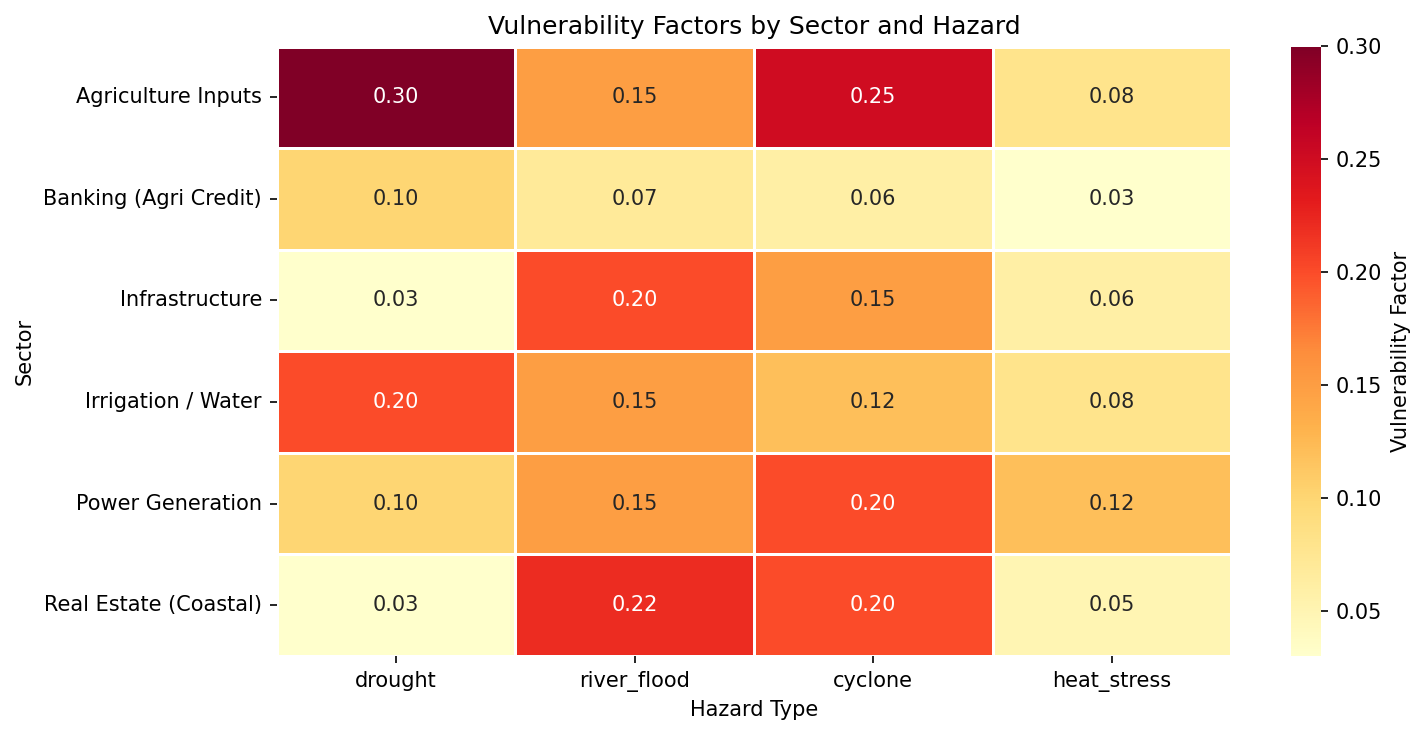

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

import seaborn as sns

vuln_pivot = vuln_df.pivot(index="sector", columns="hazard", values="vulnerability")
vuln_pivot = vuln_pivot[["drought", "river_flood", "cyclone", "heat_stress"]]

sns.heatmap(
    vuln_pivot,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Vulnerability Factor"}
)
ax.set_title("Vulnerability Factors by Sector and Hazard")
ax.set_xlabel("Hazard Type")
ax.set_ylabel("Sector")
plt.tight_layout()
savefig("vulnerability_heatmap.png")
plt.show()

In [13]:
vuln_df.to_csv(os.path.join(DATA_DIR, "vulnerability_factors.csv"), index=False)
print("Saved: vulnerability_factors.csv")

Saved: vulnerability_factors.csv


In [14]:
# Approximate market cap in INR crore (early 2026, round numbers)
# Source: NSE market data; used as asset value proxy for expected loss scaling
# Note: relative magnitudes matter more than precision here

MARKET_CAP = {
    "UPL Ltd":                   45000,
    "Coromandel International":  25000,
    "NTPC Ltd":                 350000,
    "Adani Green Energy":       100000,
    "Larsen & Toubro":          550000,
    "IRB Infrastructure":        15000,
    "State Bank of India":      700000,
    "Bank of Baroda":            65000,
    "Jain Irrigation Systems":    3500,
    "DLF Ltd":                  200000,
}

# NGFS scenario scalar for South Asian monsoon hazards
# Source: NGFS Scenarios for Central Banks and Supervisors (2022), regional annex
# Orderly Transition (1.5C) = baseline hazard probabilities from ThinkHazard
# Current Policies (4C)     = Orderly Transition x 1.5 scalar (conservative)
# Scalar applies to: river_flood, drought, cyclone
# Heat stress scalar is higher in literature but we apply uniform 1.5x for consistency

SCENARIO_SCALAR = {
    "Orderly Transition (1.5C)": 1.0,
    "Current Policies (4C)":     1.5,
}

In [15]:
# Merge vulnerability factors into the locations-hazard table
# Need to reshape: one row per company-district-hazard combination

hazard_long = locations_hazard.melt(
    id_vars=["company", "sector", "district", "state", "asset_weight"],
    value_vars=hazard_cols,
    var_name="hazard",
    value_name="hazard_prob_baseline"
)

hazard_long = hazard_long.merge(
    vuln_df,
    on=["sector", "hazard"],
    how="left"
)

print(f"Long-format table shape: {hazard_long.shape}")
print(f"Missing vulnerability values: {hazard_long['vulnerability'].isnull().sum()}")
print(hazard_long.head(8).to_string(index=False))

Long-format table shape: (120, 8)
Missing vulnerability values: 0
                 company             sector      district          state  asset_weight      hazard  hazard_prob_baseline  vulnerability
                 UPL Ltd Agriculture Inputs        Valsad        Gujarat        0.5000 river_flood                0.1000         0.1500
                 UPL Ltd Agriculture Inputs       Bharuch        Gujarat        0.3000 river_flood                0.1000         0.1500
                 UPL Ltd Agriculture Inputs      Jhagadia        Gujarat        0.2000 river_flood                0.0500         0.1500
Coromandel International Agriculture Inputs Visakhapatnam Andhra Pradesh        0.5000 river_flood                0.1000         0.1500
Coromandel International Agriculture Inputs      Kakinada Andhra Pradesh        0.3000 river_flood                0.2000         0.1500
Coromandel International Agriculture Inputs   Ranga Reddy      Telangana        0.2000 river_flood                0.10

In [16]:
results = []

for scenario, scalar in SCENARIO_SCALAR.items():
    df = hazard_long.copy()
    df["scenario"] = scenario
    df["hazard_prob"] = (df["hazard_prob_baseline"] * scalar).clip(upper=1.0)
    df["asset_value"] = df["company"].map(MARKET_CAP)

    # Expected loss at location level (INR crore)
    df["expected_loss_location"] = (
        df["asset_value"] *
        df["hazard_prob"] *
        df["vulnerability"] *
        df["asset_weight"]
    )

    results.append(df)

results_df = pd.concat(results, ignore_index=True)

print(f"Results table shape: {results_df.shape}")
print(f"Scenarios: {results_df['scenario'].unique()}")

Results table shape: (240, 12)
Scenarios: <StringArray>
['Orderly Transition (1.5C)', 'Current Policies (4C)']
Length: 2, dtype: str


In [17]:
# Aggregate: sum across districts and hazards per company per scenario
company_el = (
    results_df
    .groupby(["company", "sector", "scenario"])["expected_loss_location"]
    .sum()
    .reset_index()
    .rename(columns={"expected_loss_location": "total_expected_loss_cr"})
)

# Express as % of market cap
company_el["asset_value"] = company_el["company"].map(MARKET_CAP)
company_el["expected_loss_pct"] = (
    company_el["total_expected_loss_cr"] / company_el["asset_value"] * 100
)

print("Expected loss by company and scenario (% of market cap)")
print("=" * 70)
print(
    company_el[["company", "sector", "scenario", "expected_loss_pct"]]
    .sort_values(["scenario", "expected_loss_pct"], ascending=[True, False])
    .to_string(index=False)
)

Expected loss by company and scenario (% of market cap)
                 company                sector                  scenario  expected_loss_pct
Coromandel International    Agriculture Inputs     Current Policies (4C)            13.4400
      Adani Green Energy      Power Generation     Current Policies (4C)            11.1150
         Larsen & Toubro        Infrastructure     Current Policies (4C)            10.5563
                 UPL Ltd    Agriculture Inputs     Current Policies (4C)            10.4250
 Jain Irrigation Systems    Irrigation / Water     Current Policies (4C)            10.0785
                 DLF Ltd Real Estate (Coastal)     Current Policies (4C)             9.1913
                NTPC Ltd      Power Generation     Current Policies (4C)             8.4525
      IRB Infrastructure        Infrastructure     Current Policies (4C)             6.8475
     State Bank of India Banking (Agri Credit)     Current Policies (4C)             5.0160
          Bank of Baroda

In [18]:
# Pivot for comparison view
el_pivot = company_el.pivot_table(
    index=["company", "sector"],
    columns="scenario",
    values="expected_loss_pct"
).reset_index()

el_pivot.columns.name = None
el_pivot["incremental_risk_pp"] = (
    el_pivot["Current Policies (4C)"] - el_pivot["Orderly Transition (1.5C)"]
)
el_pivot = el_pivot.sort_values("Current Policies (4C)", ascending=False)

print("Scenario comparison: Expected Loss as % of market cap")
print("=" * 75)
print(el_pivot.to_string(index=False))

Scenario comparison: Expected Loss as % of market cap
                 company                sector  Current Policies (4C)  Orderly Transition (1.5C)  incremental_risk_pp
Coromandel International    Agriculture Inputs                13.4400                     8.9600               4.4800
      Adani Green Energy      Power Generation                11.1150                     7.4100               3.7050
         Larsen & Toubro        Infrastructure                10.5563                     7.0375               3.5188
                 UPL Ltd    Agriculture Inputs                10.4250                     6.9500               3.4750
 Jain Irrigation Systems    Irrigation / Water                10.0785                     6.7190               3.3595
                 DLF Ltd Real Estate (Coastal)                 9.1913                     6.1275               3.0637
                NTPC Ltd      Power Generation                 8.4525                     5.6350               2.8175
  

In [19]:
el_pivot.to_csv(os.path.join(DATA_DIR, "expected_loss_by_company.csv"), index=False)
results_df.to_csv(os.path.join(DATA_DIR, "expected_loss_detail.csv"), index=False)
print("Saved: expected_loss_by_company.csv")
print("Saved: expected_loss_detail.csv")

Saved: expected_loss_by_company.csv
Saved: expected_loss_detail.csv


In [20]:
# Equal weight portfolio: 10% per company
N_COMPANIES = locations["company"].nunique()
PORTFOLIO_WEIGHT = 1.0 / N_COMPANIES

print(f"Companies in portfolio : {N_COMPANIES}")
print(f"Weight per company     : {PORTFOLIO_WEIGHT:.2%}")

Companies in portfolio : 10
Weight per company     : 10.00%


In [21]:
# Portfolio expected loss = weighted average of company expected losses
portfolio_el = (
    company_el
    .groupby("scenario")
    .apply(lambda x: np.average(x["expected_loss_pct"]))
    .reset_index()
    .rename(columns={0: "portfolio_el_pct"})
)

# Total portfolio value
total_portfolio_value = sum(MARKET_CAP.values())

portfolio_el["total_portfolio_value_cr"] = total_portfolio_value
portfolio_el["portfolio_el_cr"] = (
    portfolio_el["portfolio_el_pct"] / 100 * total_portfolio_value
)

print("Portfolio-level Climate VaR (Expected Loss)")
print("=" * 60)
print(portfolio_el[["scenario", "portfolio_el_pct", "portfolio_el_cr"]].to_string(index=False))
print(f"\nTotal portfolio value : INR {total_portfolio_value:,.0f} crore")

orderly = portfolio_el.loc[
    portfolio_el["scenario"] == "Orderly Transition (1.5C)", "portfolio_el_pct"
].values[0]

current = portfolio_el.loc[
    portfolio_el["scenario"] == "Current Policies (4C)", "portfolio_el_pct"
].values[0]

incremental = current - orderly

print(f"\nPortfolio Climate VaR - Orderly Transition (1.5C) : {orderly:.2f}% of portfolio value")
print(f"Portfolio Climate VaR - Current Policies (4C)     : {current:.2f}% of portfolio value")
print(f"Incremental risk (scenario gap)                    : {incremental:.2f} pp")

Portfolio-level Climate VaR (Expected Loss)
                 scenario  portfolio_el_pct  portfolio_el_cr
    Current Policies (4C)            8.9586      183964.8510
Orderly Transition (1.5C)            5.9724      122643.2340

Total portfolio value : INR 2,053,500 crore

Portfolio Climate VaR - Orderly Transition (1.5C) : 5.97% of portfolio value
Portfolio Climate VaR - Current Policies (4C)     : 8.96% of portfolio value
Incremental risk (scenario gap)                    : 2.99 pp


✓ Saved: portfolio_climate_var.png


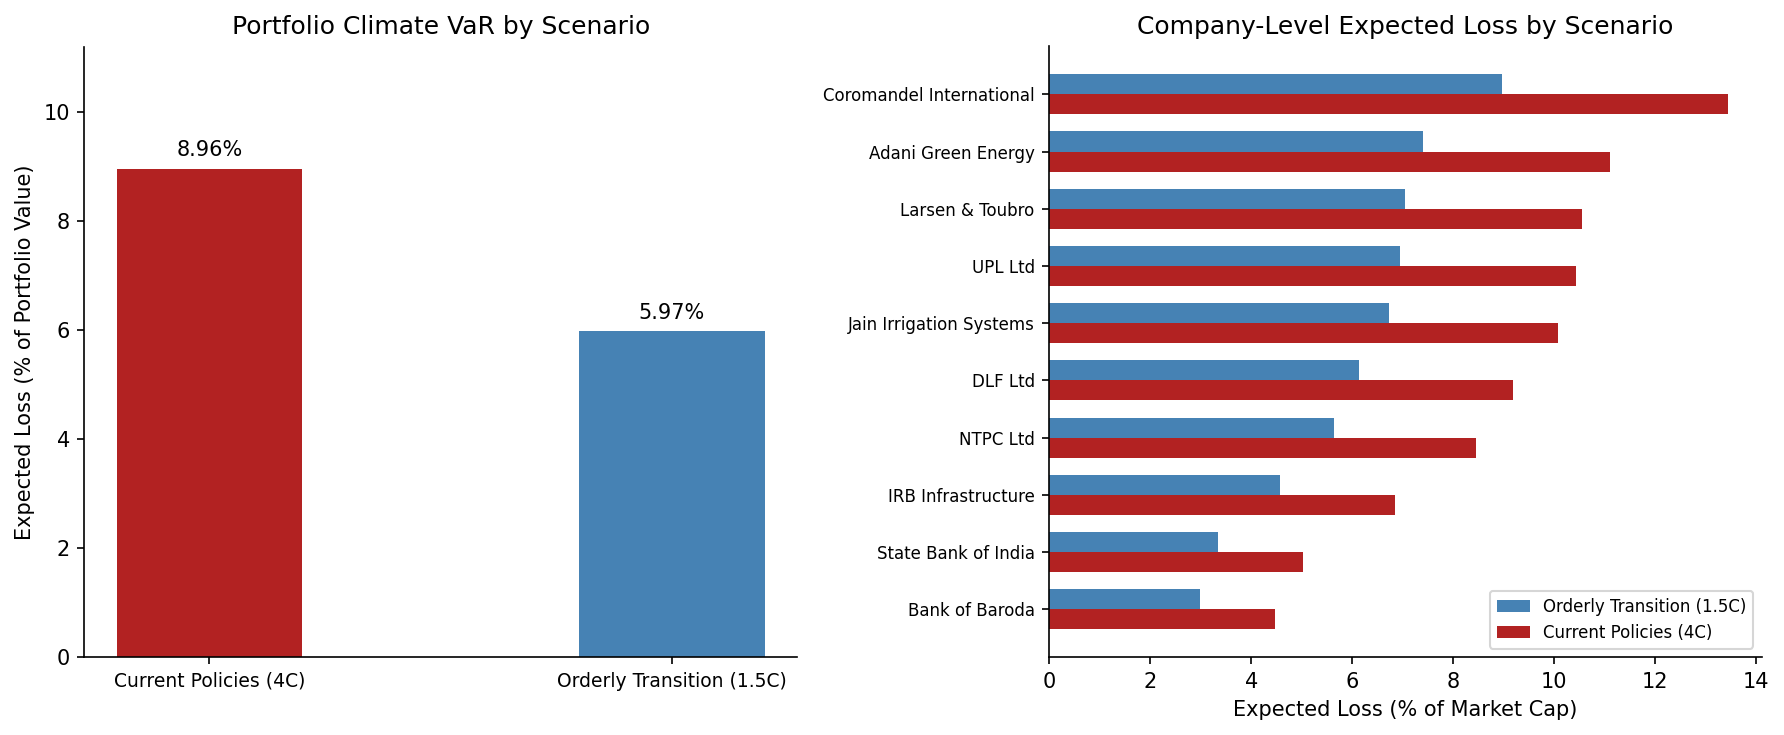

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: portfolio VaR bar chart
scenarios = portfolio_el["scenario"].tolist()
values = portfolio_el["portfolio_el_pct"].tolist()
colors = ["firebrick", "steelblue"]

bars = axes[0].bar(scenarios, values, color=colors, width=0.4)
axes[0].bar_label(bars, fmt="%.2f%%", padding=4)
axes[0].set_ylabel("Expected Loss (% of Portfolio Value)")
axes[0].set_title("Portfolio Climate VaR by Scenario")
axes[0].set_ylim(0, max(values) * 1.25)
axes[0].tick_params(axis="x", labelsize=9)

# Right: company-level expected loss under both scenarios
el_plot = el_pivot.sort_values("Current Policies (4C)", ascending=True)
y = range(len(el_plot))
height = 0.35

axes[1].barh(
    [i + height/2 for i in y],
    el_plot["Orderly Transition (1.5C)"],
    height=height,
    color="steelblue",
    label="Orderly Transition (1.5C)"
)
axes[1].barh(
    [i - height/2 for i in y],
    el_plot["Current Policies (4C)"],
    height=height,
    color="firebrick",
    label="Current Policies (4C)"
)
axes[1].set_yticks(list(y))
axes[1].set_yticklabels(el_plot["company"], fontsize=8)
axes[1].set_xlabel("Expected Loss (% of Market Cap)")
axes[1].set_title("Company-Level Expected Loss by Scenario")
axes[1].legend(fontsize=8)

plt.tight_layout()
savefig("portfolio_climate_var.png")
plt.show()

In [23]:
portfolio_el.to_csv(os.path.join(DATA_DIR, "portfolio_climate_var.csv"), index=False)
print("Saved: portfolio_climate_var.csv")

Saved: portfolio_climate_var.csv


In [24]:
# Output 1: Scenario comparison table
comparison_table = el_pivot[
    ["company", "sector",
     "Orderly Transition (1.5C)",
     "Current Policies (4C)",
     "incremental_risk_pp"]
].copy()

comparison_table.columns = [
    "Company", "Sector",
    "Orderly Transition EL (%)",
    "Current Policies EL (%)",
    "Incremental Risk (pp)"
]

comparison_table = comparison_table.sort_values(
    "Current Policies EL (%)", ascending=False
).reset_index(drop=True)

print("Output 1: Scenario Comparison Table")
print("=" * 85)
print(comparison_table.to_string(index=False))

comparison_table.to_csv(
    os.path.join(DATA_DIR, "output1_scenario_comparison.csv"), index=False
)
print("\nSaved: output1_scenario_comparison.csv")

Output 1: Scenario Comparison Table
                 Company                Sector  Orderly Transition EL (%)  Current Policies EL (%)  Incremental Risk (pp)
Coromandel International    Agriculture Inputs                     8.9600                  13.4400                 4.4800
      Adani Green Energy      Power Generation                     7.4100                  11.1150                 3.7050
         Larsen & Toubro        Infrastructure                     7.0375                  10.5563                 3.5188
                 UPL Ltd    Agriculture Inputs                     6.9500                  10.4250                 3.4750
 Jain Irrigation Systems    Irrigation / Water                     6.7190                  10.0785                 3.3595
                 DLF Ltd Real Estate (Coastal)                     6.1275                   9.1913                 3.0637
                NTPC Ltd      Power Generation                     5.6350                   8.4525            

✓ Saved: output2_sector_heatmap.png


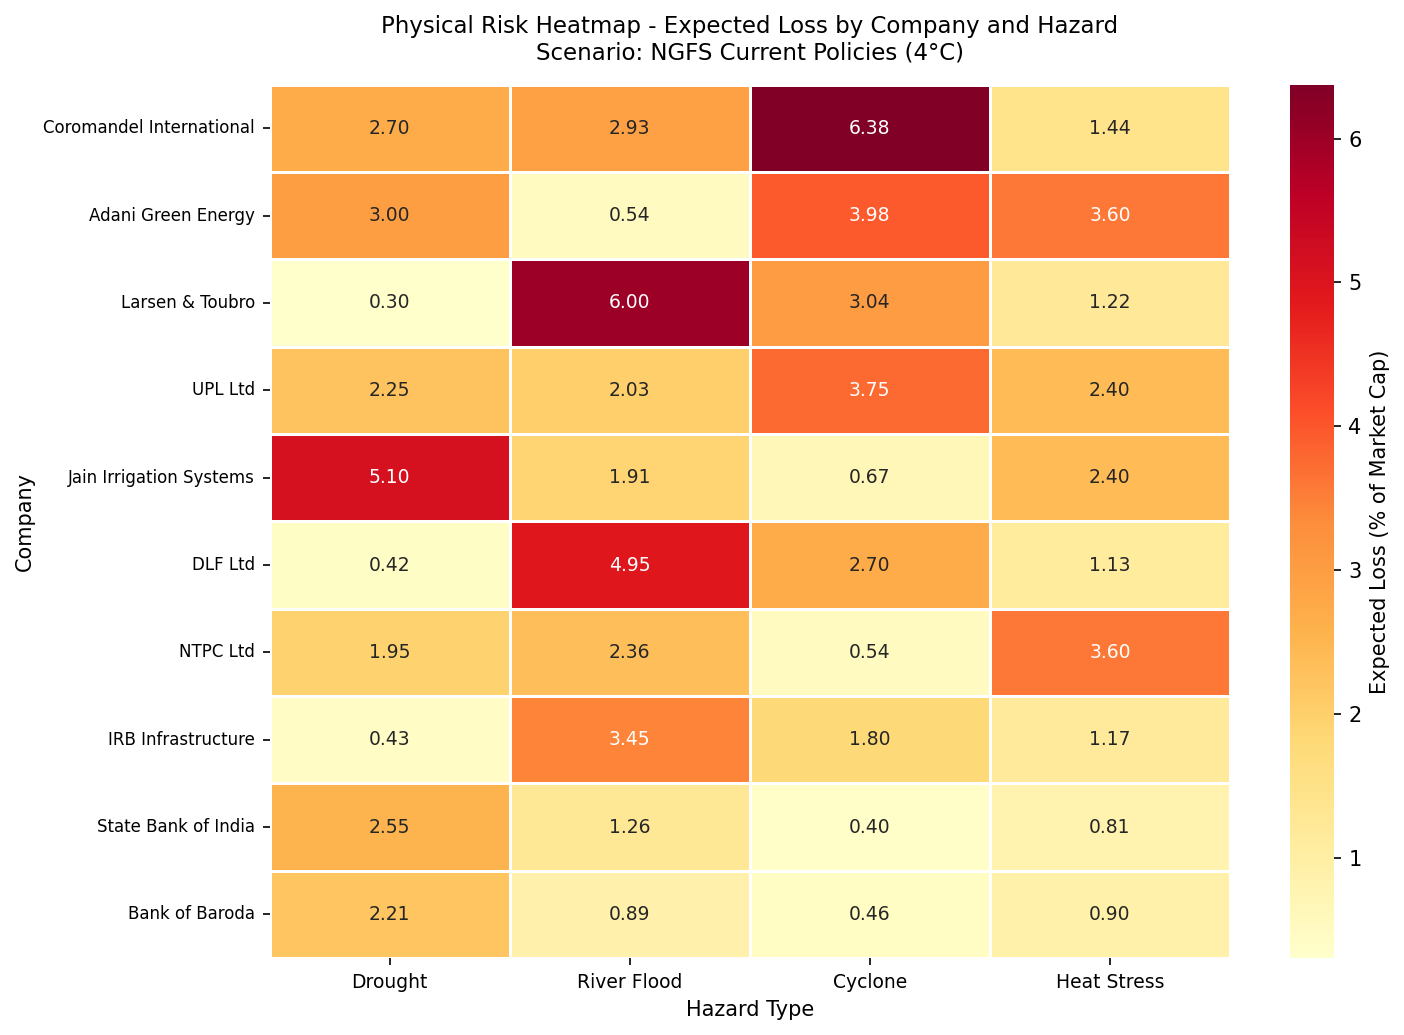

In [25]:
# Output 2: Sector heatmap
# Rows: companies, Columns: hazard types
# Cell value: expected loss contribution from that hazard under Current Policies (4C)

heatmap_data = (
    results_df[results_df["scenario"] == "Current Policies (4C)"]
    .groupby(["company", "hazard"])["expected_loss_location"]
    .sum()
    .reset_index()
)

heatmap_data["asset_value"] = heatmap_data["company"].map(MARKET_CAP)
heatmap_data["el_pct"] = heatmap_data["expected_loss_location"] / heatmap_data["asset_value"] * 100

heatmap_pivot = heatmap_data.pivot(
    index="company", columns="hazard", values="el_pct"
).fillna(0)

heatmap_pivot = heatmap_pivot[["drought", "river_flood", "cyclone", "heat_stress"]]

company_order = (
    comparison_table.set_index("Company")["Current Policies EL (%)"]
    .sort_values(ascending=False)
    .index.tolist()
)
heatmap_pivot = heatmap_pivot.loc[company_order]

col_labels = {
    "drought":     "Drought",
    "river_flood": "River Flood",
    "cyclone":     "Cyclone",
    "heat_stress": "Heat Stress"
}
heatmap_pivot.columns = [col_labels[c] for c in heatmap_pivot.columns]

fig, ax = plt.subplots(figsize=(10, 7))

import seaborn as sns

sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Expected Loss (% of Market Cap)"},
    annot_kws={"size": 9}
)

ax.set_title(
    "Physical Risk Heatmap - Expected Loss by Company and Hazard\n"
    "Scenario: NGFS Current Policies (4°C)",
    fontsize=11, pad=12
)
ax.set_xlabel("Hazard Type", fontsize=10)
ax.set_ylabel("Company", fontsize=10)
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=8, rotation=0)

plt.tight_layout()
savefig("output2_sector_heatmap.png")
plt.show()

✓ Saved: output3_portfolio_summary.png


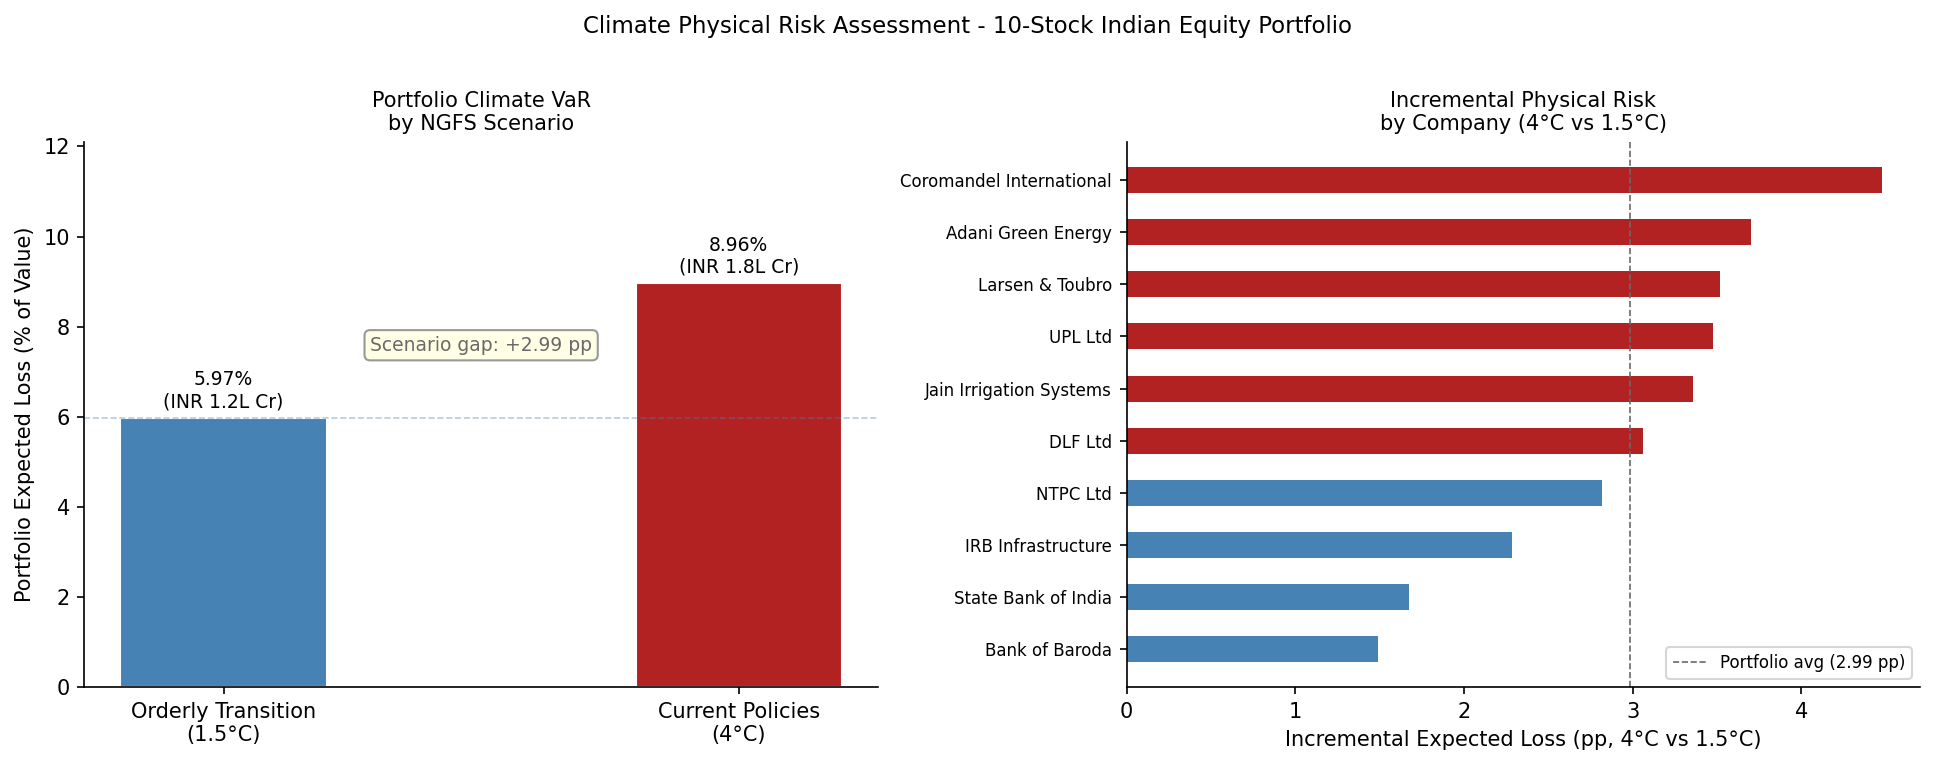

In [26]:
# Output 3: Portfolio summary chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: portfolio VaR under both scenarios with INR crore annotation
scenarios_plot = ["Orderly Transition\n(1.5°C)", "Current Policies\n(4°C)"]
el_vals = [orderly, current]
el_cr_vals = [
    portfolio_el.loc[portfolio_el["scenario"] == "Orderly Transition (1.5C)",
                     "portfolio_el_cr"].values[0],
    portfolio_el.loc[portfolio_el["scenario"] == "Current Policies (4C)",
                     "portfolio_el_cr"].values[0]
]
colors = ["steelblue", "firebrick"]

bars = axes[0].bar(scenarios_plot, el_vals, color=colors, width=0.4, edgecolor="white")

for bar, pct, cr in zip(bars, el_vals, el_cr_vals):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{pct:.2f}%\n(INR {cr/1e5:.1f}L Cr)",
        ha="center", va="bottom", fontsize=9
    )

axes[0].set_ylabel("Portfolio Expected Loss (% of Value)")
axes[0].set_title("Portfolio Climate VaR\nby NGFS Scenario", fontsize=10)
axes[0].set_ylim(0, max(el_vals) * 1.35)
axes[0].axhline(
    y=orderly, color="steelblue", linestyle="--", alpha=0.4, linewidth=0.8
)

axes[0].annotate(
    f"Scenario gap: +{incremental:.2f} pp",
    xy=(0.5, (orderly + current) / 2),
    xycoords=("axes fraction", "data"),
    ha="center", fontsize=9, color="dimgray",
    bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray", alpha=0.8)
)

# Right panel: incremental risk by company (waterfall-style bar)
inc_plot = el_pivot.sort_values("incremental_risk_pp", ascending=True)

bar_colors = [
    "firebrick" if v > incremental else "steelblue"
    for v in inc_plot["incremental_risk_pp"]
]

axes[1].barh(
    inc_plot["company"],
    inc_plot["incremental_risk_pp"],
    color=bar_colors,
    height=0.5
)
axes[1].axvline(
    x=incremental, color="dimgray", linestyle="--",
    linewidth=0.8, label=f"Portfolio avg ({incremental:.2f} pp)"
)
axes[1].set_xlabel("Incremental Expected Loss (pp, 4°C vs 1.5°C)")
axes[1].set_title("Incremental Physical Risk\nby Company (4°C vs 1.5°C)", fontsize=10)
axes[1].tick_params(axis="y", labelsize=8)
axes[1].legend(fontsize=8)

plt.suptitle(
    "Climate Physical Risk Assessment - 10-Stock Indian Equity Portfolio",
    fontsize=11, y=1.01
)
plt.tight_layout()
savefig("output3_portfolio_summary.png")
plt.show()

In [27]:
print("Output summary")
print("=" * 55)
print(f"Portfolio Climate VaR (Orderly Transition, 1.5C) : {orderly:.2f}%")
print(f"Portfolio Climate VaR (Current Policies, 4C)     : {current:.2f}%")
print(f"Incremental risk                                  : {incremental:.2f} pp")
print(f"Highest risk company (4C)                         : {comparison_table.iloc[0]['Company']}")
print(f"Highest risk sector                               : {comparison_table.iloc[0]['Sector']}")
print(f"Lowest risk company (4C)                          : {comparison_table.iloc[-1]['Company']}")
print()
print("Files saved to outputs/:")
print("  output1_scenario_comparison.csv")
print("  output2_sector_heatmap.png")
print("  output3_portfolio_summary.png")
print("  portfolio_climate_var.png")
print("  vulnerability_heatmap.png")
print("  portfolio_composition.png")

Output summary
Portfolio Climate VaR (Orderly Transition, 1.5C) : 5.97%
Portfolio Climate VaR (Current Policies, 4C)     : 8.96%
Incremental risk                                  : 2.99 pp
Highest risk company (4C)                         : Coromandel International
Highest risk sector                               : Agriculture Inputs
Lowest risk company (4C)                          : Bank of Baroda

Files saved to outputs/:
  output1_scenario_comparison.csv
  output2_sector_heatmap.png
  output3_portfolio_summary.png
  portfolio_climate_var.png
  vulnerability_heatmap.png
  portfolio_composition.png


In [28]:
# Run this cell to confirm all output numbers are available for the write-up
print(f"Orderly Transition VaR : {orderly:.2f}%")
print(f"Current Policies VaR   : {current:.2f}%")
print(f"Incremental risk       : {incremental:.2f} pp")
print(f"Highest risk company   : {comparison_table.iloc[0]['Company']}")
print(f"Highest risk sector    : {comparison_table.iloc[0]['Sector']}")
print(f"Portfolio value        : INR {total_portfolio_value:,.0f} crore")

Orderly Transition VaR : 5.97%
Current Policies VaR   : 8.96%
Incremental risk       : 2.99 pp
Highest risk company   : Coromandel International
Highest risk sector    : Agriculture Inputs
Portfolio value        : INR 2,053,500 crore


## Methodology

### Framework

This analysis follows the TCFD (Task Force on Climate-related Financial Disclosures)
framework for physical risk assessment. The TCFD distinguishes two categories of
climate risk: physical risk (direct damage from climate hazards such as floods,
droughts, and cyclones) and transition risk (policy, technology, and market shifts
associated with moving to a low-carbon economy). This project addresses physical
risk only. Transition risk is excluded and noted as a limitation.

### Scenario Definition

Two NGFS (Network for Greening the Financial System) scenarios are used:

- **Orderly Transition (1.5°C):** Strong early climate policy action; physical
  hazard probabilities remain at current baseline levels. Corresponds approximately
  to SSP1-2.6 in the CMIP6 framework.
- **Current Policies (4°C):** No significant additional policy action beyond
  current commitments; physical hazard probabilities increase materially across
  South Asian monsoon-related perils. Corresponds approximately to SSP5-8.5.

The NGFS Scenarios for Central Banks and Supervisors (2022) documents approximately
1.5x to 2x increase in extreme precipitation event frequency and cyclone intensity
for South Asia under the high-emission pathway relative to the low-emission pathway.
This analysis applies a conservative 1.5x scalar to baseline hazard probabilities
for the Current Policies scenario across all four hazard types. This scalar is
applied uniformly; a more granular implementation would use hazard-specific and
region-specific multipliers derived from CMIP6 model ensembles.

### Expected Loss Model

The core calculation follows the standard physical risk three-factor model:

```
Expected Loss = Asset Value x Hazard Probability x Vulnerability Factor
```

**Asset Value** is proxied by approximate market capitalisation in INR crore as of
early 2026. For companies with assets distributed across multiple districts, the
market cap is allocated across locations using asset weights estimated from annual
report disclosures (plant capacities, revenue concentration, project site values).

**Hazard Probability** is the annual exceedance probability (AEP) for each hazard
at each asset location. Qualitative hazard ratings (High / Medium / Low / Very Low)
were sourced from ThinkHazard (GFDRR / World Bank) at the district level for four
perils: river flood, drought, tropical cyclone, and heat stress. Ratings were
converted to AEP proxies as follows: High = 0.20, Medium = 0.10, Low = 0.05,
Very Low = 0.01. These conversions are approximations consistent with UNDRR hazard
classification literature.

**Vulnerability Factor** is the fraction of asset value or revenue lost given the
hazard occurs. Factors are assigned at the sector-hazard level based on:
- IPCC AR6 Working Group II sector chapters (agriculture Ch.5, energy Ch.6,
  urban/infrastructure Ch.13) for damage range estimates
- CLIMADA ETH documentation for asset-type vulnerability curves
- Expert judgment with documented rationale for banking (second-order exposure)

Banking sector entries represent second-order physical risk: drought and flood
events impair agricultural borrowers, which raises NPA ratios, which reduces
bank revenue. The vulnerability factor for banking captures this credit
transmission channel, not direct physical asset damage.

### Aggregation

Expected loss is computed for every company-district-hazard combination, then
aggregated to the company level by summing across districts (weighted by
asset_weight) and across hazards. Portfolio-level expected loss is the equal-weighted
average across all 10 companies (10% allocation per company).

The portfolio metric reported is **expected loss as a percentage of portfolio value**
- the probability-weighted mean loss under each scenario. This is the first moment
of the loss distribution, not a percentile-based VaR. A full Climate VaR would
require a simulated loss distribution (e.g. via Monte Carlo over the hazard
probability space) to report a loss at a specified confidence level (e.g. 95th
percentile). This distinction is acknowledged as a methodological limitation.

### Limitations

- **Hazard resolution:** ThinkHazard ratings are district-level qualitative classes
  derived from global datasets. A rigorous implementation would use return-period
  curves from CMIP6 or IMD gridded data at sub-district resolution.
- **Vulnerability point estimates:** Vulnerability factors are single scalars, not
  damage functions. A damage function maps hazard intensity (e.g. flood depth in
  metres) to loss fraction continuously. Point estimates ignore the nonlinearity
  of damage at extreme intensities.
- **Scenario scalar:** The 1.5x hazard probability multiplier for Current Policies
  is a uniform approximation. NGFS documentation and CMIP6 outputs show
  hazard-specific and region-specific multipliers that vary materially from this
  central estimate.
- **Loss correlation:** Company-level losses are treated as independent. In reality,
  a severe monsoon season affects multiple companies simultaneously - correlations
  approach 1 during systemic climate events, which would increase portfolio tail
  losses above what expected loss arithmetic captures.
- **Transition risk excluded:** This assessment covers physical risk only. For a
  complete TCFD-aligned analysis, transition risk (carbon pricing, stranded assets,
  policy shifts) would need to be modelled separately and combined.
- **Asset location data:** Company asset locations are sourced from NSE annual
  report disclosures, which are self-reported, may lag by up to one year, and
  may not reflect the full geographic distribution of revenue-generating assets.
- **Market cap as asset value proxy:** Market capitalisation reflects forward-looking
  earnings expectations, not replacement value of physical assets. A more precise
  implementation would use asset replacement value or insured value at each location.

## Analyst Summary

This assessment quantifies the annual expected loss from physical climate hazards
for a 10-stock Indian equity portfolio spanning agriculture inputs, power generation,
infrastructure, banking, irrigation, and real estate sectors.

Under the NGFS Orderly Transition scenario (1.5°C), the portfolio carries an annual
expected loss of **5.97% of total value** (approximately INR 1.23 lakh crore).
Under the NGFS Current Policies scenario (4°C), this rises to **8.96%**
(approximately INR 1.84 lakh crore) - an incremental 2.99 percentage points
attributable to the higher hazard frequency projected under the high-emission pathway.

The highest physical risk exposure is in the **Agriculture Inputs** sector.
Coromandel International leads the portfolio at 13.44% expected loss under Current
Policies, driven by its concentration in coastal Andhra Pradesh districts rated High
for both cyclone and river flood hazard. Adani Green Energy (11.12%) ranks second,
reflecting cyclone exposure at its Gujarat coastal wind and solar assets - a result
that challenges the assumption that renewable energy assets are inherently low
physical risk.

Banking sector exposures (SBI, Bank of Baroda) are lowest at 4-5%, consistent with
their second-order exposure profile: physical hazards affect these companies through
agricultural credit quality deterioration rather than direct asset damage.

The 2.99 pp scenario gap represents the quantifiable cost of the divergence between
a managed climate transition and a high-emission pathway, expressed as an annual
portfolio loss metric. Key limitations include the use of qualitative hazard proxies
rather than return-period curves, point-estimate vulnerability factors rather than
continuous damage functions, and the exclusion of loss correlation across companies.

In [29]:
# Copy final result table in outputs/
import os
import shutil

shutil.copy(
    os.path.join(DATA_DIR, "output1_scenario_comparison.csv"),
    os.path.join(OUTPUT_DIR, "output1_scenario_comparison.csv")
)
print("Copied: output1_scenario_comparison.csv -> outputs/")


Copied: output1_scenario_comparison.csv -> outputs/


In [30]:
# Confirm all output files exist
expected_outputs = [
    "portfolio_composition.png",
    "vulnerability_heatmap.png",
    "output2_sector_heatmap.png",
    "output3_portfolio_summary.png",
    "portfolio_climate_var.png",
    "output1_scenario_comparison.csv",
]

print("Output file check")
print("=" * 45)
all_present = True
for f in expected_outputs:
    path = os.path.join(OUTPUT_DIR, f)
    exists = os.path.exists(path)
    status = "OK" if exists else "MISSING"
    print(f"  {status}  {f}")
    if not exists:
        all_present = False

print(f"\nAll outputs present: {all_present}")

Output file check
  OK  portfolio_composition.png
  OK  vulnerability_heatmap.png
  OK  output2_sector_heatmap.png
  OK  output3_portfolio_summary.png
  OK  portfolio_climate_var.png
  OK  output1_scenario_comparison.csv

All outputs present: True
